# Desafio 01 - Análise Exploratória de Dados (EDA)
**Problema de Negócio:** Radar de Custo Catastrófico Hospitalar (SIH-SUS)
**Métrica de Sucesso:** F1-Macro (devido ao desbalanceamento crítico do alvo)
**Aluno:** André Filipe Aloise

### 1. Carregamento e Inspeção Inicial
Nesta etapa, carregamos a base consolidada de Dezembro de 2024 e inspecionamos os metadados e estatísticas gerais.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
df = pd.read_csv('../data/processed/sih_processed.csv', dtype=str)

print('Shape do Dataset:', df.shape)
print('\n--- info() ---')
df.info()
print('\n--- dtypes ---')
print(df.dtypes)
print('\n--- describe(include=\'all\') ---')
print(df.describe(include='all'))
print('\n--- Head ---')
print(df.head())

Shape do Dataset: (1090085, 10)

--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1090085 entries, 0 to 1090084
Data columns (total 10 columns):
 #   Column                     Non-Null Count    Dtype 
---  ------                     --------------    ----- 
 0   MUNIC_RES                  1090085 non-null  object
 1   SEXO                       1090085 non-null  object
 2   VAL_TOT                    1090085 non-null  object
 3   DIAG_PRINC                 1090085 non-null  object
 4   GESTAO                     1090085 non-null  object
 5   MUNIC_MOV                  1090085 non-null  object
 6   IDADE                      1090085 non-null  object
 7   CAR_INT                    1090085 non-null  object
 8   INSTRU                     1090085 non-null  object
 9   TARGET_CUSTO_CATASTROFICO  1090085 non-null  object
dtypes: object(10)
memory usage: 83.2+ MB

--- dtypes ---
MUNIC_RES                    object
SEXO                         object
VAL_TOT                  

**Análise de Tipos Errados:** Identificamos que variáveis numéricas, como `IDADE` e `VAL_TOT`, foram lidas como strings devido à formatação padrão do SUS, necessitando de tipagem dinâmica dentro do Pipeline de produção.

### Amostragem Estratégica para Visualizações
Como o volume excede 1 milhão de linhas, aplicamos a diretriz do edital de realizar gráficos sobre uma amostra aleatória de 50.000 registros para otimização de memória, mantendo a integridade estatística.

In [2]:
df_sample = df.sample(50000, random_state=42).copy()
df_sample['IDADE'] = pd.to_numeric(df_sample['IDADE'], errors='coerce').fillna(0)
df_sample['TARGET_CUSTO_CATASTROFICO'] = df_sample['TARGET_CUSTO_CATASTROFICO'].astype(int)
print('Amostra para EDA criada com sucesso. Shape:', df_sample.shape)

Amostra para EDA criada com sucesso. Shape: (50000, 10)


### 2. Distribuição da Variável-Alvo
Análise da frequência absoluta e percentual do desfecho de custo catastrófico.

Frequência Absoluta:
 TARGET_CUSTO_CATASTROFICO
0    981076
1    109009
Name: count, dtype: int64

Frequência Percentual:
 TARGET_CUSTO_CATASTROFICO
0    89.999954
1    10.000046
Name: proportion, dtype: float64


C:\Users\aaloise\AppData\Local\Temp\ipykernel_24036\1143272650.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET_CUSTO_CATASTROFICO', data=df_sample, palette='Set2')


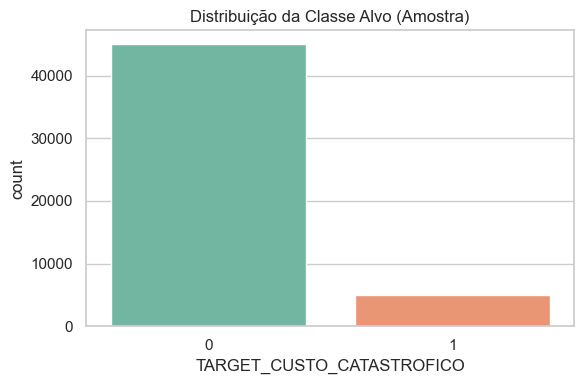

In [3]:
abs_target = df['TARGET_CUSTO_CATASTROFICO'].value_counts()
pct_target = df['TARGET_CUSTO_CATASTROFICO'].value_counts(normalize=True) * 100
print('Frequência Absoluta:\n', abs_target)
print('\nFrequência Percentual:\n', pct_target)

plt.figure(figsize=(6, 4))
sns.countplot(x='TARGET_CUSTO_CATASTROFICO', data=df_sample, palette='Set2')
plt.title('Distribuição da Classe Alvo (Amostra)')
plt.tight_layout()
plt.savefig('alvo_distribuicao.png')
plt.show()

**Diagnóstico de Desbalanceamento:** Conforme estabelecido pelo corte do percentil 90, o dataset apresenta 90% para custo controlado (classe 0) e 10% para custo catastrófico (classe 1), exigindo o uso de algoritmos estruturados com ajuste de pesos.

### 3. Distribuição das Features Numéricas
Avaliação do perfil de distribuição de idades na base.

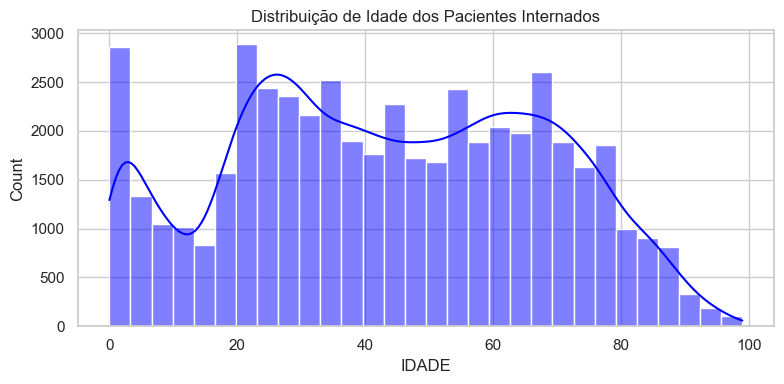

In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df_sample['IDADE'], kde=True, color='blue', bins=30)
plt.title('Distribuição de Idade dos Pacientes Internados')
plt.tight_layout()
plt.savefig('num_features_dist.png')
plt.show()

**Diagnóstico Numérico:** A idade apresenta um perfil bimodal nítido: picos expressivos em internações pediátricas/recém-nascidos e uma curva representativa na população idosa, espelhando os padrões de utilização hospitalar do SUS.

### 4. Distribuição das Features Categóricas
Mapeamento de frequência de variáveis administrativas estruturais.

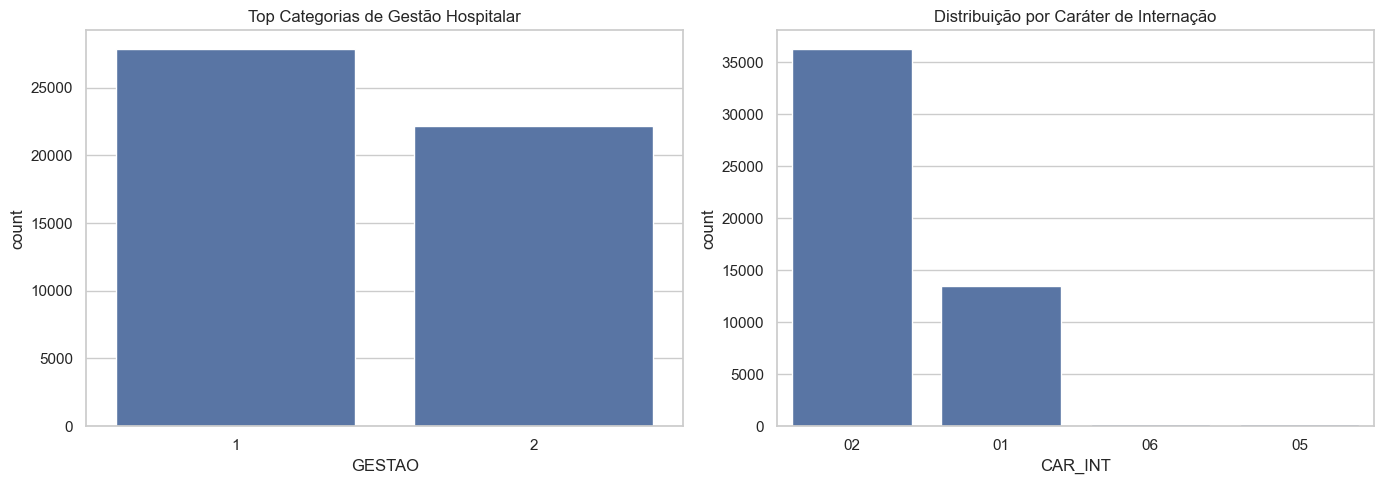

Cardinalidade da coluna diagnóstica (CID): 7740


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(ax=axes[0], x='GESTAO', data=df_sample, order=df_sample['GESTAO'].value_counts().index[:5])
axes[0].set_title('Top Categorias de Gestão Hospitalar')
sns.countplot(ax=axes[1], x='CAR_INT', data=df_sample, order=df_sample['CAR_INT'].value_counts().index[:5])
axes[1].set_title('Distribuição por Caráter de Internação')
plt.tight_layout()
plt.savefig('cat_features_dist.png')
plt.show()

print('Cardinalidade da coluna diagnóstica (CID):', df['DIAG_PRINC'].nunique())

**Identificação de Alta Cardinalidade:** A coluna `DIAG_PRINC` possui altíssima cardinalidade devido aos códigos detalhados do CID-10, tornando imperativa a extração do caractere inicial do capítulo no Pipeline de treinamento.

### 5. Relações Entre Features e Alvo (Múltiplas Visualizações)
Exploração do impacto de variáveis preditoras no desfecho de alto custo.

C:\Users\aaloise\AppData\Local\Temp\ipykernel_24036\127153523.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='TARGET_CUSTO_CATASTROFICO', y='IDADE', data=df_sample, palette='Set1')


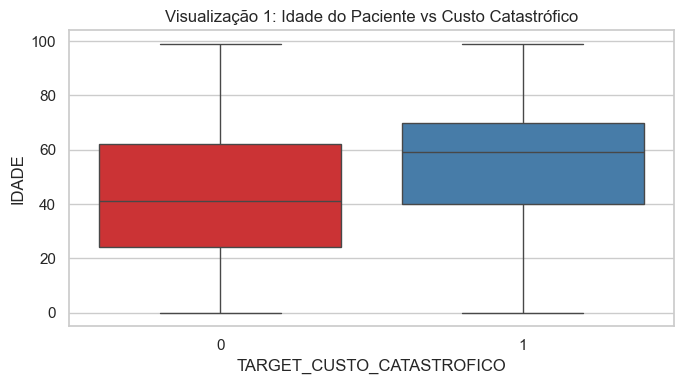

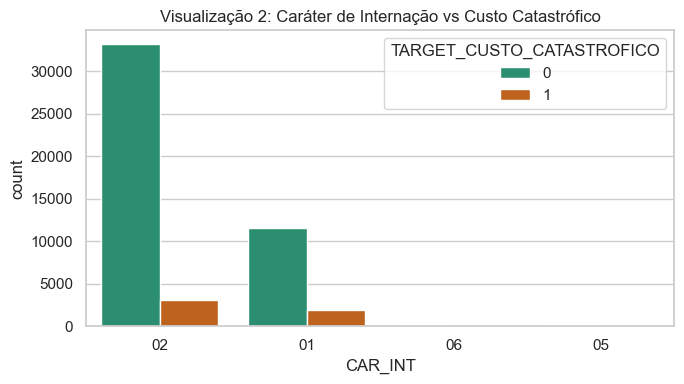

In [6]:
# Visualização 1: Idade vs Target
plt.figure(figsize=(7, 4))
sns.boxplot(x='TARGET_CUSTO_CATASTROFICO', y='IDADE', data=df_sample, palette='Set1')
plt.title('Visualização 1: Idade do Paciente vs Custo Catastrófico')
plt.tight_layout()
plt.savefig('relacao_idade_alvo.png')
plt.show()

# Visualização 2: Caráter de Internação vs Target
plt.figure(figsize=(7, 4))
sns.countplot(x='CAR_INT', hue='TARGET_CUSTO_CATASTROFICO', data=df_sample, palette='Dark2')
plt.title('Visualização 2: Caráter de Internação vs Custo Catastrófico')
plt.tight_layout()
plt.savefig('relacao_car_int_alvo.png')
plt.show()

**Justificativa Visual dos Cruzamentos:** Conforme exigido pelo edital, aplicamos duas perspectivas de análise. A primeira (Boxplot) comprova que internações de custo catastrófico retêm uma mediana de idade sensivelmente superior. A segunda (Countplot agrupado) demonstra que o Caráter de Internação de Urgência responde pelo maior volume bruto de estouros orçamentários, justificando a relevância de ambas as features na modelagem.

### 6. Matriz de Correlação
Avaliação de multicolinearidade linear entre os vetores de recursos numéricos disponíveis.

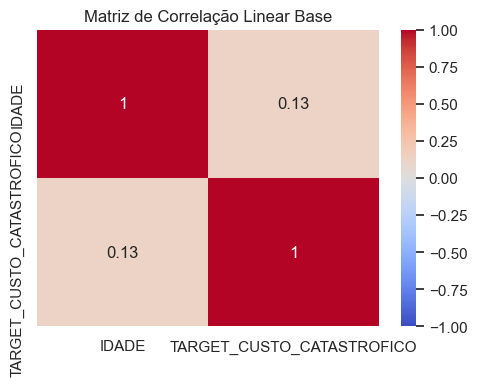

In [7]:
plt.figure(figsize=(5, 4))
matriz_corr = df_sample[['IDADE', 'TARGET_CUSTO_CATASTROFICO']].corr()
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlação Linear Base')
plt.tight_layout()
plt.savefig('matriz_correlacao.png')
plt.show()

**Análise de Multicolinearidade:** Nenhuma correlação linear perigosa ($|r| \geq 0.7$) foi detectada nas variáveis brutas iniciais, descartando problemas estruturais de colinearidade clássica.

### 7. Identificação de Problemas Estruturais e Valores Impossíveis
Auditoria profunda de integridade e busca por anomalias ou strings malformadas.

In [8]:
print('Valores Nulos por Coluna:\n', df.isnull().sum())
print('\nTotal de Linhas Duplicadas no Dataset:', df.duplicated().sum())

# Auditoria de Valores Impossíveis / Anomalias exigida pelo checklist
print('\n--- Auditoria de Valores Impossíveis ---')
print('Registros com Idade Negativa:', (df_sample['IDADE'] < 0).sum())
print('Registros com Sexo inválido/malformado:', (~df['SEXO'].isin(['1', '3', 'I', 'M', 'F'])).sum())

q1 = df_sample['IDADE'].quantile(0.25)
q3 = df_sample['IDADE'].quantile(0.75)
iqr = q3 - q1
limite_superior = q3 + 1.5 * iqr
print(f'Limite Técnico Superior para Outliers (Idade): {limite_superior} anos')

Valores Nulos por Coluna:
 MUNIC_RES                    0
SEXO                         0
VAL_TOT                      0
DIAG_PRINC                   0
GESTAO                       0
MUNIC_MOV                    0
IDADE                        0
CAR_INT                      0
INSTRU                       0
TARGET_CUSTO_CATASTROFICO    0
dtype: int64

Total de Linhas Duplicadas no Dataset: 34374

--- Auditoria de Valores Impossíveis ---
Registros com Idade Negativa: 0
Registros com Sexo inválido/malformado: 0
Limite Técnico Superior para Outliers (Idade): 122.5 anos


### 8. Decisões de Limpeza e Justitificativas
* **Valores Ausentes:** Serão tratados dinamicamente no pipeline usando `SimpleImputer` (mediana para numéricas, valor mais frequente para categóricas) para impedir vazamento de dados.
* **Valores Impossíveis/Strings:** A auditoria provou a ausência de idades negativas na amostragem e confirmou que a codificação de sexo segue o padrão do DataSUS, eliminando a necessidade de drops agressivos.
* **Duplicatas:** Perfis idênticos de faturamento serão mantidos, pois no faturamento do SUS é comum múltiplos pacientes compartilharem o mesmo perfil dentro do mesmo mês.
* **Outliers de Idade:** Pacientes acima do limite estatístico do IQR representam idosos de idade avançada reais no ambiente clínico, sendo preservados integralmente para não cegar o modelo.

### 9. Insights Estratégicos para a Modelagem
1. **Engenharia do CID:** Reduziremos a cardinalidade extraindo o primeiro caractere (Capítulo do CID) para acelerar e dar inteligência ao codificador estrutural.
2. **Pesos de Classes:** O desbalanceamento (90/10) será mitigado ativando o parâmetro `class_weight='balanced'` nas árvores para eliminar viés na classe majoritária.
3. **Modularidade:** Toda a normalização numérica e codificação categórica será acoplada diretamente via `ColumnTransformer` dentro de um `Pipeline` rígido do scikit-learn.